# 01 — Data Pipeline
**Goal**: Load earnings call transcripts → build event metadata → download market data
→ compute Abnormal Returns, CAR, and ΔVol.

This notebook calls functions from `src/nasdaq_nlp/` and shows the outputs at each step.

In [3]:
import os
from pathlib import Path

# Move to project root so relative paths work (notebooks/ is one level down)
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))


## Step 1: Load Transcripts

We have 188 earnings call transcripts across 10 NASDAQ firms (2016–2020).
Each file is a Thomson Reuters StreetEvents (newspaper agency) document in plain text format.

In [4]:
from nasdaq_nlp.data.loader import scan_transcripts, count_by_ticker

records = scan_transcripts()  # returns list[TranscriptRecord]
print(f"Total transcripts: {len(records)}")
print("By ticker:", count_by_ticker(records))

Total transcripts: 188
By ticker: {'AAPL': 19, 'AMD': 19, 'AMZN': 19, 'ASML': 19, 'CSCO': 19, 'GOOGL': 19, 'INTC': 19, 'MSFT': 19, 'MU': 17, 'NVDA': 19}


## Step 2: Event Metadata

For the event study to work, we need to know exactly which **trading day**
the market could react to each call. We call this the event (i.e., earnings call) metadata

**The rule** (US markets):
- If the call is before 4 PM Eastern Time → same-day event
- If the call is at/after 4 PM ET (after market close) → next business day

We parse the timestamp from each transcript header and apply this rule.

In [8]:
from nasdaq_nlp.data.metadata import build_event_metadata

meta = build_event_metadata()
print(f"Events: {len(meta)}")
print()
# Show time-of-day distribution
print("Calls after market close:", meta['after_market_close'].sum(), "/", len(meta))
print()
meta.head(10)

Found 188 transcripts across 10 tickers
Saved event metadata → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/processed/event_metadata.csv  (188 rows)
Events: 188

Calls after market close: 169 / 188



,ticker,file_name,file_path,year,quarter,call_datetime_gmt,call_datetime_et,call_time_et,after_market_close,event_trading_day
0,AAPL,2016-Jan-26-AAPL.txt,/Users/javierdominguezsegura/Academics/College...,2016,Q1,2016-01-26 22:00:00,2016-01-26 17:00:00,17:00,True,2016-01-27
1,AAPL,2016-Apr-26-AAPL.txt,/Users/javierdominguezsegura/Academics/College...,2016,Q2,2016-04-26 21:00:00,2016-04-26 17:00:00,17:00,True,2016-04-27
2,AAPL,2016-Jul-26-AAPL.txt,/Users/javierdominguezsegura/Academics/College...,2016,Q3,2016-07-26 21:00:00,2016-07-26 17:00:00,17:00,True,2016-07-27
3,AAPL,2016-Oct-25-AAPL.txt,/Users/javierdominguezsegura/Academics/College...,2016,Q4,2016-10-25 21:00:00,2016-10-25 17:00:00,17:00,True,2016-10-26
4,AAPL,2017-Jan-31-AAPL.txt,/Users/javierdominguezsegura/Academics/College...,2017,Q1,2017-01-31 22:00:00,2017-01-31 17:00:00,17:00,True,2017-02-01
5,AAPL,2017-May-02-AAPL.txt,/Users/javierdominguezsegura/Academics/College...,2017,Q2,2017-05-02 21:00:00,2017-05-02 17:00:00,17:00,True,2017-05-03
6,AAPL,2017-Aug-01-AAPL.txt,/Users/javierdominguezsegura/Academics/College...,2017,Q3,2017-08-01 21:00:00,2017-08-01 17:00:00,17:00,True,2017-08-02
7,AAPL,2017-Nov-02-AAPL.txt,/Users/javierdominguezsegura/Academics/College...,2017,Q4,2017-11-02 21:00:00,2017-11-02 17:00:00,17:00,True,2017-11-03
8,AAPL,2018-Feb-01-AAPL.txt,/Users/javierdominguezsegura/Academics/College...,2018,Q1,2018-02-01 22:00:00,2018-02-01 17:00:00,17:00,True,2018-02-02
9,AAPL,2018-May-01-AAPL.txt,/Users/javierdominguezsegura/Academics/College...,2018,Q2,2018-05-01 21:00:00,2018-05-01 17:00:00,17:00,True,2018-05-02


Lets inspect who is having the earnings call while the stock market is open:

In [9]:
meta[meta["after_market_close"] == False]

,ticker,file_name,file_path,year,quarter,call_datetime_gmt,call_datetime_et,call_time_et,after_market_close,event_trading_day
57,ASML,2016-Jan-20-ASML.txt,/Users/javierdominguezsegura/Academics/College...,2016,Q1,2016-01-20 14:00:00,2016-01-20 09:00:00,09:00,False,2016-01-20
58,ASML,2016-Apr-20-ASML.txt,/Users/javierdominguezsegura/Academics/College...,2016,Q2,2016-04-20 13:00:00,2016-04-20 09:00:00,09:00,False,2016-04-20
59,ASML,2016-Jul-20-ASML.txt,/Users/javierdominguezsegura/Academics/College...,2016,Q3,2016-07-20 13:00:00,2016-07-20 09:00:00,09:00,False,2016-07-20
60,ASML,2016-Oct-19-ASML.txt,/Users/javierdominguezsegura/Academics/College...,2016,Q4,2016-10-19 13:00:00,2016-10-19 09:00:00,09:00,False,2016-10-19
61,ASML,2017-Jan-18-ASML.txt,/Users/javierdominguezsegura/Academics/College...,2017,Q1,2017-01-18 14:00:00,2017-01-18 09:00:00,09:00,False,2017-01-18
62,ASML,2017-Apr-19-ASML.txt,/Users/javierdominguezsegura/Academics/College...,2017,Q2,2017-04-19 13:00:00,2017-04-19 09:00:00,09:00,False,2017-04-19
63,ASML,2017-Jul-19-ASML.txt,/Users/javierdominguezsegura/Academics/College...,2017,Q3,2017-07-19 13:00:00,2017-07-19 09:00:00,09:00,False,2017-07-19
64,ASML,2017-Oct-18-ASML.txt,/Users/javierdominguezsegura/Academics/College...,2017,Q4,2017-10-18 13:00:00,2017-10-18 09:00:00,09:00,False,2017-10-18
65,ASML,2018-Jan-17-ASML.txt,/Users/javierdominguezsegura/Academics/College...,2018,Q1,2018-01-17 14:00:00,2018-01-17 09:00:00,09:00,False,2018-01-17
66,ASML,2018-Apr-18-ASML.txt,/Users/javierdominguezsegura/Academics/College...,2018,Q2,2018-04-18 13:00:00,2018-04-18 09:00:00,09:00,False,2018-04-18


This makes sense given the fact that ASML is a dutch company and live in a different timezone (GMT +2). 

## Step 3: Market Data and Returns

We download daily Adjusted Close prices from Yahoo Finance (yfinance) for all 10 tickers
and the NASDAQ Composite index (^IXIC).

**Math — Simple daily return:**

$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

where $P_t$ is the Adjusted Close price on day $t$.
We use *Adjusted* Close (accounts for splits and dividends) so corporate actions post-trading day
don't create fake return spikes.

In [10]:
from nasdaq_nlp.data.market import build_market_returns

# This downloads data if not already cached
stocks, index = build_market_returns()
print(f"Stock return rows: {len(stocks)} | Index return rows: {len(index)}")
print(f"Date range: {stocks['date'].min().date()} → {stocks['date'].max().date()}")
print()
stocks.groupby('ticker')['return'].describe().round(4)

  Date range: 2015-06-29 → 2020-09-19
  → AAPL ✓ (1317 rows)
  → AMD ✓ (1317 rows)
  → AMZN ✓ (1317 rows)
  → ASML ✓ (1317 rows)
  → CSCO ✓ (1317 rows)
  → GOOGL ✓ (1317 rows)
  → INTC ✓ (1317 rows)
  → MSFT ✓ (1317 rows)
  → MU ✓ (1317 rows)
  → NVDA ✓ (1317 rows)
Saved raw prices → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/processed/prices_raw.csv  (13170 rows)
Saved stock returns  → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/processed/stock_returns.csv  (13160 rows)
Saved index returns  → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/processed/index_returns.csv  (1316 rows)
Stock return rows: 13160 | Index return rows: 1316
Date range: 2015-06-30 → 2020-09-18



,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
AAPL,1316.0,0.0012,0.0188,-0.1286,-0.0062,0.0009,0.0098,0.1198
AMD,1316.0,0.0035,0.0415,-0.2423,-0.0173,0.0016,0.0218,0.5229
AMZN,1316.0,0.0016,0.0191,-0.0792,-0.0068,0.0016,0.0108,0.1322
ASML,1316.0,0.0012,0.0208,-0.1735,-0.0086,0.0016,0.0119,0.1161
CSCO,1316.0,0.0006,0.0172,-0.1118,-0.0064,0.0009,0.0081,0.1337
GOOGL,1316.0,0.0009,0.0172,-0.1163,-0.0059,0.0012,0.0090,0.1626
INTC,1316.0,0.0007,0.0204,-0.1804,-0.0077,0.0010,0.0094,0.1952
MSFT,1316.0,0.0014,0.0175,-0.1474,-0.0059,0.0013,0.0090,0.1422
MU,1316.0,0.0012,0.0311,-0.1982,-0.0152,0.0010,0.0185,0.1334


## Step 4: Market Model (OLS), Abnormal Returns, CAR, and ΔVol

**The Market Model (OLS):**

For each earnings call event $i$, we fit a linear regression in the
estimation window (trading days −120 to −20 relative to the call):

$$R_{i,t} = \alpha_i + \beta_i R_{m,t} + \varepsilon_{i,t}$$

- $R_{i,t}$ = stock return on trading day $t$
- $R_{m,t}$ = NASDAQ index return (market return)
- $\alpha_i$ = stock's idiosyncratic excess return
- $\beta_i$ = market sensitivity (e.g. $\beta > 1$ → amplifies market moves)
- $\varepsilon_{i,t}$ = unexplained residual

**Abnormal Return:**

$$AR_{i,t} = R_{i,t} - (\hat{\alpha}_i + \hat{\beta}_i R_{m,t})$$

The *abnormal return* is what the stock returned *beyond* what the market
model predicted — i.e. the earnings-call "surprise."

**Cumulative Abnormal Return (CAR):**

$$\text{CAR}_i[0,3] = AR_{i,0} + AR_{i,1} + AR_{i,2} + AR_{i,3}$$

We sum ARs over a multi-day window to capture the full market reaction
(markets can react over multiple sessions).

**Volatility Change:**

$$\Delta\text{Vol}_i = \sigma(R_{i,+1..+10}) - \sigma(R_{i,-10..-1})$$

Captures whether the call *increased* or *decreased* return variability.

In [11]:
from nasdaq_nlp.models.market_model import build_event_study

event_study = build_event_study()
print(f"Events with complete data: {event_study['car_03'].notna().sum()}")
print()
print("Summary of CAR[0,3] and ΔVol:")
event_study[['car_01','car_03','ar_0','delta_vol']].describe().round(4)

Events: 188 | Stock return rows: 13160 | Index rows: 1316
Building event-time panel...
Panel: 24628 rows across 188 events
Estimating market models (OLS)...
  Fitted 188 models (events with ≥30 estimation observations)
Computing abnormal returns and CAR...
Computing volatility change...
Saved market model   → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/processed/market_model.csv
Saved event study    → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/processed/event_study_dataset.csv  (188 rows)
Events with complete data: 188

Summary of CAR[0,3] and ΔVol:


,car_01,car_03,ar_0,delta_vol
count,188.0000,188.0000,188.0000,188.0000
mean,0.0091,0.0077,0.0085,0.0014
std,0.0824,0.0935,0.0778,0.0105
min,-0.2682,-0.3112,-0.2484,-0.0502
25%,-0.0351,-0.0382,-0.0367,-0.0040
50%,0.0095,0.0048,0.0105,0.0007
75%,0.0445,0.0546,0.0432,0.0064
max,0.3954,0.4776,0.5317,0.0485


In [12]:
event_study

,event_id,ticker,file_name,event_trading_day,alpha,beta,n_obs_estimation,car_01,car_03,ar_0,pre_vol,post_vol,delta_vol,file_path,year,quarter
0,0,AAPL,2016-Jan-26-AAPL.txt,2016-01-27,-0.000387,1.102995,101,-0.043241,-0.045064,-0.041293,0.024005,0.018419,-0.005587,/Users/javierdominguezsegura/Academics/College...,2016,Q1
1,1,AAPL,2016-Apr-26-AAPL.txt,2016-04-27,-0.000282,1.079775,101,-0.074182,-0.089001,-0.056742,0.010551,0.012455,0.001904,/Users/javierdominguezsegura/Academics/College...,2016,Q2
2,2,AAPL,2016-Jul-26-AAPL.txt,2016-07-27,-0.000466,0.854235,101,0.071902,0.084408,0.060455,0.009706,0.010494,0.000788,/Users/javierdominguezsegura/Academics/College...,2016,Q3
3,3,AAPL,2016-Oct-25-AAPL.txt,2016-10-26,0.001067,0.864597,101,-0.023161,-0.029067,-0.018140,0.004998,0.009293,0.004296,/Users/javierdominguezsegura/Academics/College...,2016,Q4
4,4,AAPL,2017-Jan-31-AAPL.txt,2017-02-01,0.000399,0.885351,101,0.055093,0.063649,0.056189,0.005383,0.004957,-0.000426,/Users/javierdominguezsegura/Academics/College...,2017,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,183,NVDA,2019-Aug-15-NVDA.txt,2019-08-16,-0.000537,1.781203,101,0.090154,0.090223,0.043395,0.030122,0.033744,0.003622,/Users/javierdominguezsegura/Academics/College...,2019,Q3
184,184,NVDA,2019-Nov-14-NVDA.txt,2019-11-15,0.001903,1.881969,101,-0.006606,-0.010199,-0.042316,0.013463,0.026262,0.012799,/Users/javierdominguezsegura/Academics/College...,2019,Q4
185,185,NVDA,2020-Feb-13-NVDA.txt,2020-02-14,0.000939,1.861163,101,0.087744,0.124338,0.065584,0.023081,0.049832,0.026752,/Users/javierdominguezsegura/Academics/College...,2020,Q1
186,186,NVDA,2020-May-21-NVDA.txt,2020-05-22,0.003372,1.428601,101,-0.020823,-0.058586,0.019121,0.027390,0.021859,-0.005531,/Users/javierdominguezsegura/Academics/College...,2020,Q2


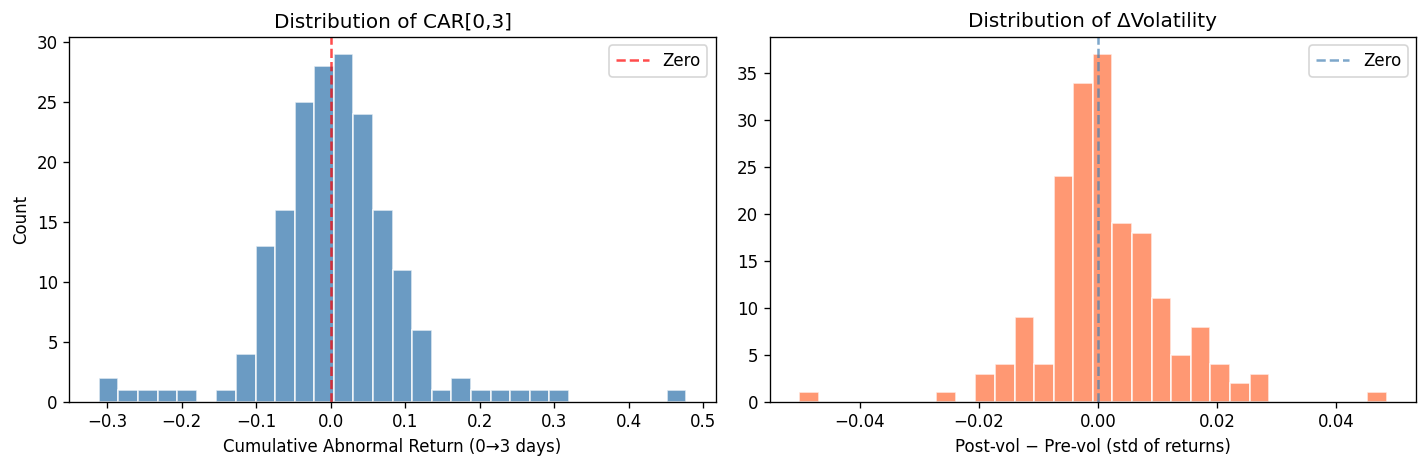

Saved → outputs/results/distributions.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# CAR[0,3] distribution
axes[0].hist(event_study['car_03'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero')
axes[0].set_title('Distribution of CAR[0,3]')
axes[0].set_xlabel('Cumulative Abnormal Return (0→3 days)')
axes[0].set_ylabel('Count')
axes[0].legend()

# ΔVol distribution
axes[1].hist(event_study['delta_vol'].dropna(), bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='steelblue', linestyle='--', alpha=0.7, label='Zero')
axes[1].set_title('Distribution of ΔVolatility')
axes[1].set_xlabel('Post-vol − Pre-vol (std of returns)')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/results/distributions.png', bbox_inches='tight')
plt.show()
print("Saved → outputs/results/distributions.png")

## Verification
Check that all 188 events have complete data (no NaN CAR values).

In [14]:
nan_car = event_study['car_03'].isna().sum()
nan_vol = event_study['delta_vol'].isna().sum()
assert nan_car == 0, f"FAIL: {nan_car} events have NaN CAR[0,3]"
assert len(event_study) == 188, f"FAIL: expected 188 events, got {len(event_study)}"
print(f"✓ All {len(event_study)} events have complete CAR and ΔVol data")
print(f"✓ {nan_vol} events with NaN ΔVol (expected 0)")

✓ All 188 events have complete CAR and ΔVol data
✓ 0 events with NaN ΔVol (expected 0)
